<a href="https://colab.research.google.com/github/DianaM38/Introducci-nAprendisajeAutomatico_MineriaDeDatos/blob/main/An%C3%A1lisis_PIA_MD_Equipo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PASO 1: Importar librerías y cargar datos

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Cargar el dataset
df = pd.read_csv('dataset.csv')

PASO 2: Selección de atributos (Vista minable)

In [4]:
# Nos quedamos solo con las variables de "sonido" para agrupar
features = ['energy', 'danceability', 'valence', 'tempo', 'acousticness']
X = df[features].dropna() # Eliminamos valores nulos si los hay

PASO 3: Preprocesamiento (Escalado de datos)

In [5]:
# Estandarizamos para que el tempo no domine sobre la energía
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

PASO 4: Determinar el número óptimo de clústeres (Método del Codo), fluctúamos el valor de K y gráficamos con el valor de wccs para ver el punto óptimo de grupos a hacer

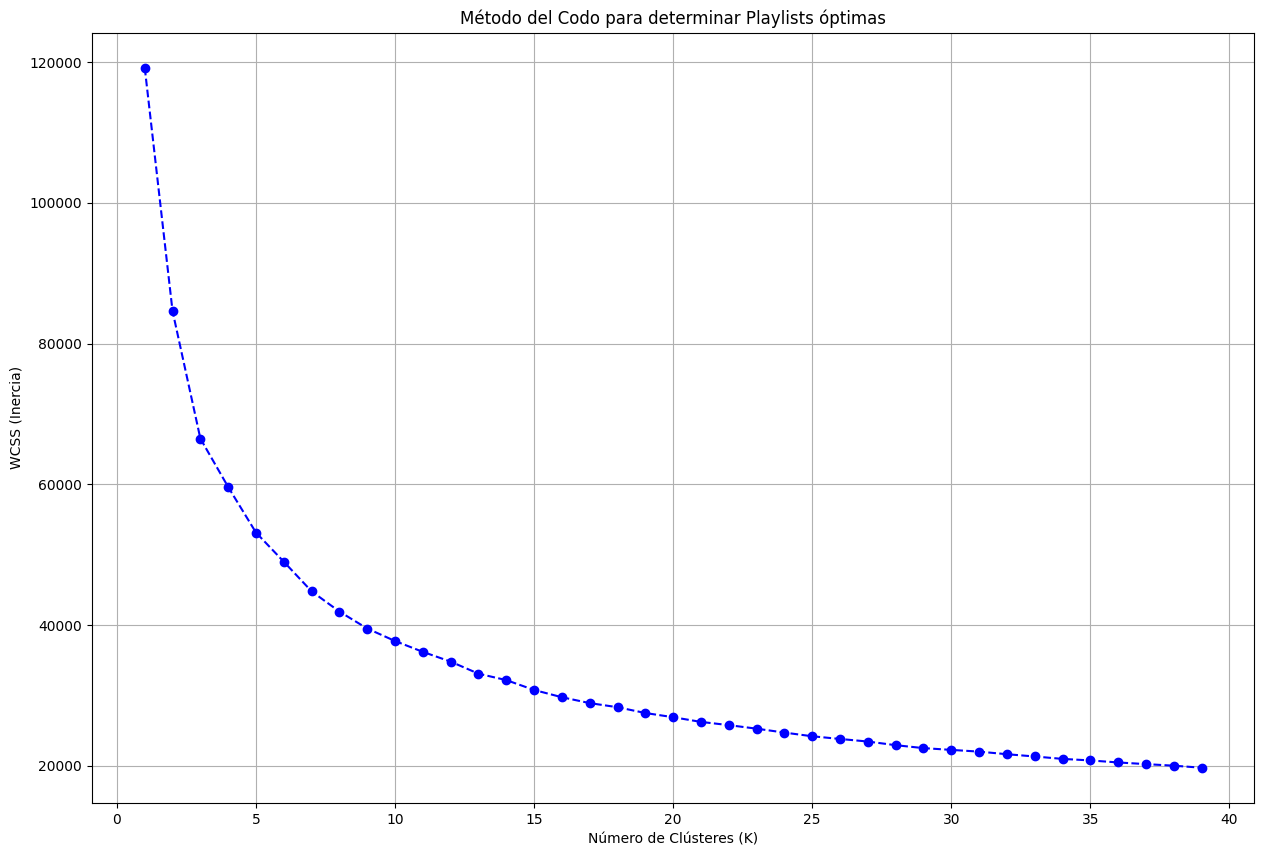

In [6]:
wcss = []
K_range = range(1, 40)

for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=30)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el Método del Codo
plt.figure(figsize=(15, 10))
plt.plot(K_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Método del Codo para determinar Playlists óptimas')
plt.xlabel('Número de Clústeres (K)')
plt.ylabel('WCSS (Inercia)')
plt.grid(True)
plt.show()

Al analizar la gráfica del Método del Codo extendida hasta K=55, se observa que la mayor reducción de la Inercia (WCSS) se detiene de forma abrupta alrededor de K=7. A partir de este punto, la curva se estabiliza, por lo que se determinó que 7 es el número óptimo de agrupaciones (Playlists) para segmentar el perfil acústico sin sobreajustar el modelo

PASO 5: Entrenar el Modelo Final K-Means

In [11]:
kmeans_final = KMeans(n_clusters=7, init='k-means++', random_state=42)
cluster_labels = kmeans_final.fit_predict(X_scaled)

# Crear una Serie de pandas con las etiquetas de clúster y el índice de X
# Esto asegura que las etiquetas se asignen a las filas correctas del DataFrame original
cluster_series = pd.Series(cluster_labels, index=X.index)

# Asignar la Serie al DataFrame original. Las filas que no estaban en X (debido a dropna)
# tendrán un valor NaN en la columna 'playlist_cluster' si no existen en X.index.
df['playlist_cluster'] = cluster_series

PASO 6: Analizar el perfil sonoro agrupando en el DataFrame original Y el modelo creado

In [12]:
cluster_summary = df.groupby('playlist_cluster')[features].mean().round(2)
print(cluster_summary)

                  energy  danceability  valence   tempo  acousticness
playlist_cluster                                                     
0.0                 0.75          0.55     0.66  163.07          0.20
1.0                 0.50          0.65     0.58  102.13          0.68
2.0                 0.73          0.61     0.34  110.72          0.11
3.0                 0.86          0.33     0.21  134.80          0.03
4.0                 0.74          0.73     0.74  115.38          0.13
5.0                 0.22          0.37     0.20   86.59          0.83
6.0                 0.30          0.49     0.30  141.53          0.76


/tmp/ipykernel_1375/2049903322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')


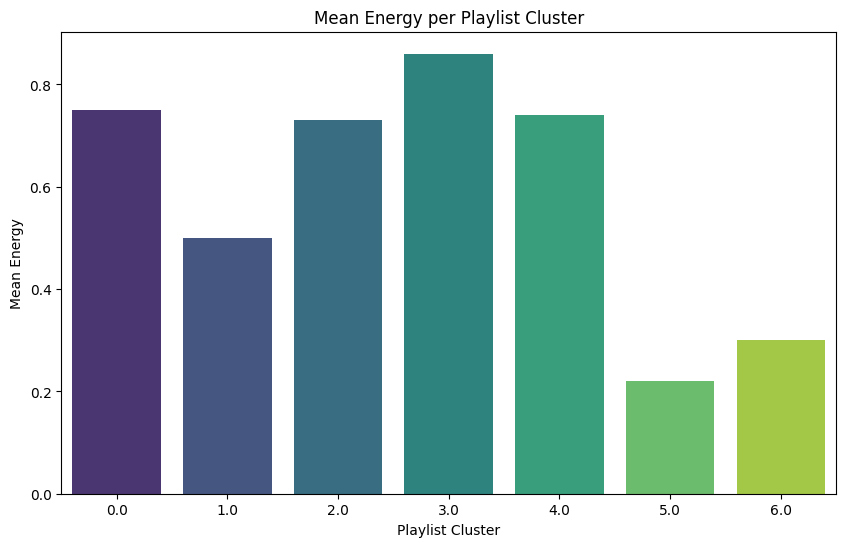

/tmp/ipykernel_1375/2049903322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')


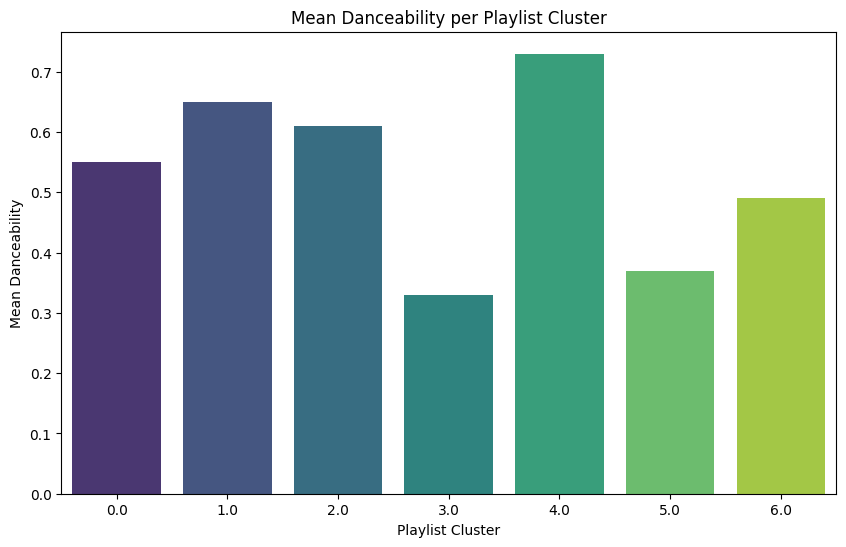

/tmp/ipykernel_1375/2049903322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')


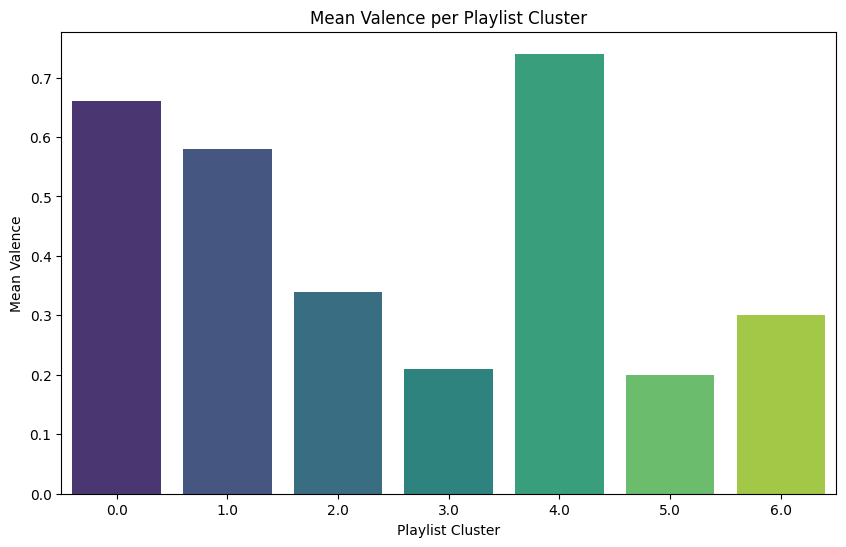

/tmp/ipykernel_1375/2049903322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')


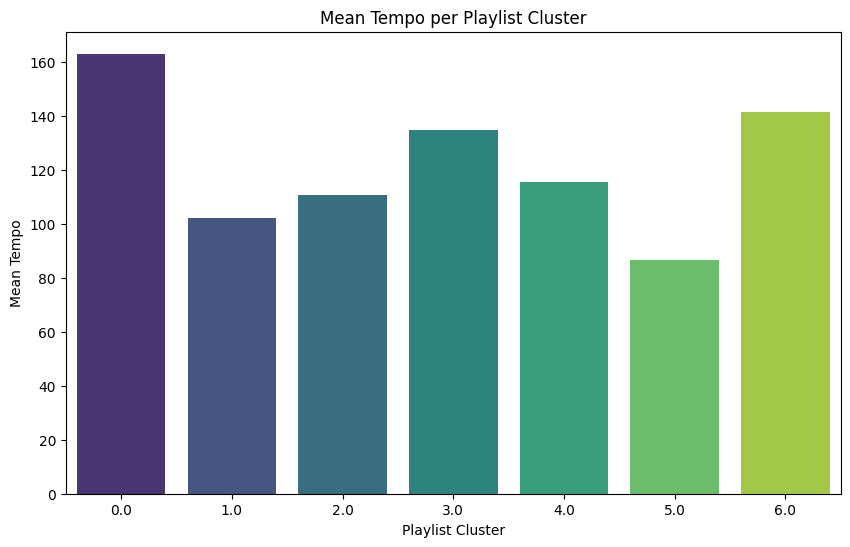

/tmp/ipykernel_1375/2049903322.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')


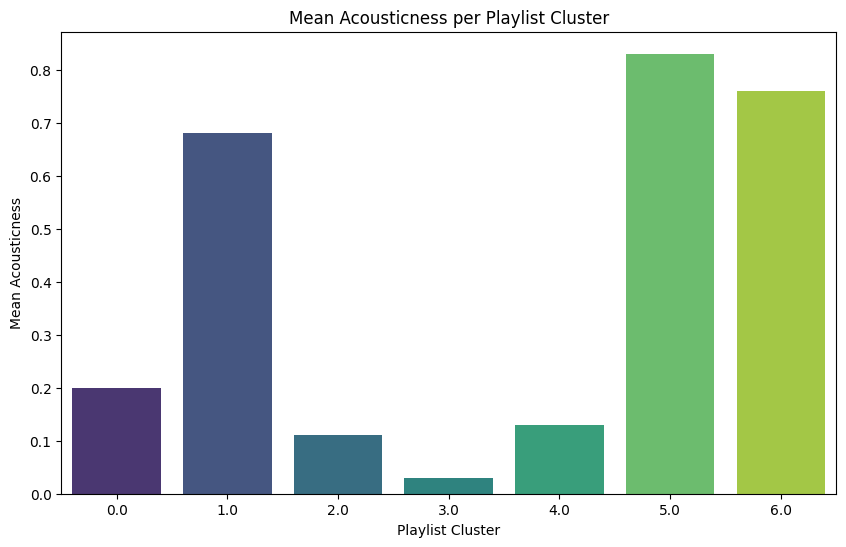

In [15]:
for caracteristica in features:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=cluster_summary.index, y=caracteristica, data=cluster_summary, palette='viridis')
    plt.title(f'Mean {caracteristica.capitalize()} per Playlist Cluster')
    plt.xlabel('Playlist Cluster')
    plt.ylabel(f'Mean {caracteristica.capitalize()}')
    plt.show()


#CLASIFICACIÓN DE GÉNERO MUSICAL
El objetivo es determinar el genero de una canción sin conocer su artista/nombre de la canción usando un modelo KNN, nuestra variable objetivo sera track_genre

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23843 entries, 0 to 23842
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        23843 non-null  int64  
 1   track_id          23843 non-null  object 
 2   artists           23842 non-null  object 
 3   album_name        23842 non-null  object 
 4   track_name        23842 non-null  object 
 5   popularity        23842 non-null  float64
 6   duration_ms       23842 non-null  float64
 7   explicit          23842 non-null  object 
 8   danceability      23842 non-null  float64
 9   energy            23842 non-null  float64
 10  key               23842 non-null  float64
 11  loudness          23842 non-null  float64
 12  mode              23842 non-null  float64
 13  speechiness       23842 non-null  float64
 14  acousticness      23842 non-null  float64
 15  instrumentalness  23842 non-null  float64
 16  liveness          23842 non-null  float6

importo las librerias que voy a usar y decido que caracteristicas usar para mi modelo

In [78]:
#knn_features = ['danceability', 'energy', 'valence', 'duration_ms', 'loudness', 'liveness','popularity', 'acousticness','tempo']
knn_target = 'track_genre'
knn_features= df.select_dtypes(include=['number']).columns.tolist()
# knn_features.remove(knn_target) # This line caused the error because knn_target is not a numerical column
cleaned_df = df.dropna(subset=knn_features + [knn_target])

knn_X = cleaned_df[knn_features]
knn_y = cleaned_df[knn_target]

knnXtrain, knnXtest, knnYtrain, knnYtest = train_test_split(knn_X, knn_y, test_size=0.2, random_state=42)

NOTA: Al momento de hacer este modelo, quite columnas (la linea de codigo documentada) y eso hizo que mi modelo KNN tuviera un porcentaje de exactitud del 49.3% y random forest de 56.57% y al observar la matriz de confusión, especificamente la diagonal principal de randomForest, nuestro modelo no esta clasificando de forma mayoritariamente incorrecta, a excepción de alternative y alt-rock las cuales si confunde demasiado, crei que la forma en la que podiamos mejorar ambos modelos (knn y randomforest) era teniendo mas registros pero era agregando todas las columnas (a exepcion de la objetivo)

In [115]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
knnXtrain_scaled = scaler.fit_transform(knnXtrain)
knnXtest_scaled = scaler.transform(knnXtest)

param_grid = {
    'metric': ['euclidean', 'manhattan', 'minkowski'],
    'n_neighbors': [11, 5, 7, 3]
}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(knnXtrain, knnYtrain)

print("Mejores parámetros:", grid.best_params_)
print("Mejor puntuación de validación cruzada:", grid.best_score_)
print("Puntuación en el conjunto de prueba:", grid.score(knnXtest, knnYtest))
print(grid.get_params())

Mejores parámetros: {'metric': 'manhattan', 'n_neighbors': 3}
Mejor puntuación de validación cruzada: 0.8032295584797954
Puntuación en el conjunto de prueba: 0.8307821346194171
{'cv': 5, 'error_score': nan, 'estimator__algorithm': 'auto', 'estimator__leaf_size': 30, 'estimator__metric': 'minkowski', 'estimator__metric_params': None, 'estimator__n_jobs': None, 'estimator__n_neighbors': 5, 'estimator__p': 2, 'estimator__weights': 'uniform', 'estimator': KNeighborsClassifier(), 'n_jobs': None, 'param_grid': {'metric': ['euclidean', 'manhattan', 'minkowski'], 'n_neighbors': [11, 5, 7, 3]}, 'pre_dispatch': '2*n_jobs', 'refit': True, 'return_train_score': False, 'scoring': 'accuracy', 'verbose': 0}


In [111]:
knn = grid.best_estimator_

In [112]:
knn.fit(knnXtrain, knnYtrain)
y_pred_knn = knn.predict(knnXtest)
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
print("Exactitud del modelo:", accuracy_score(knnYtest, y_pred_knn))
print("\nReporte de clasificación:\n", classification_report(knnYtest, y_pred_knn))

Exactitud del modelo: 0.8307821346194171

Reporte de clasificación:
                precision    recall  f1-score   support

     acoustic       0.90      0.86      0.88       189
     afrobeat       0.70      0.83      0.76       173
     alt-rock       0.84      0.80      0.82       206
  alternative       0.85      0.85      0.85       235
      ambient       0.83      0.74      0.78       209
        anime       0.78      0.85      0.81       199
  black-metal       0.77      0.82      0.79       190
    bluegrass       0.84      0.83      0.84       184
        blues       0.83      0.81      0.82       206
       brazil       0.74      0.74      0.74       193
    breakbeat       0.76      0.78      0.77       193
      british       0.83      0.73      0.78       188
     cantopop       0.82      0.88      0.85       205
chicago-house       0.87      0.87      0.87       195
     children       0.90      0.92      0.91       214
        chill       0.85      0.88      0.86      

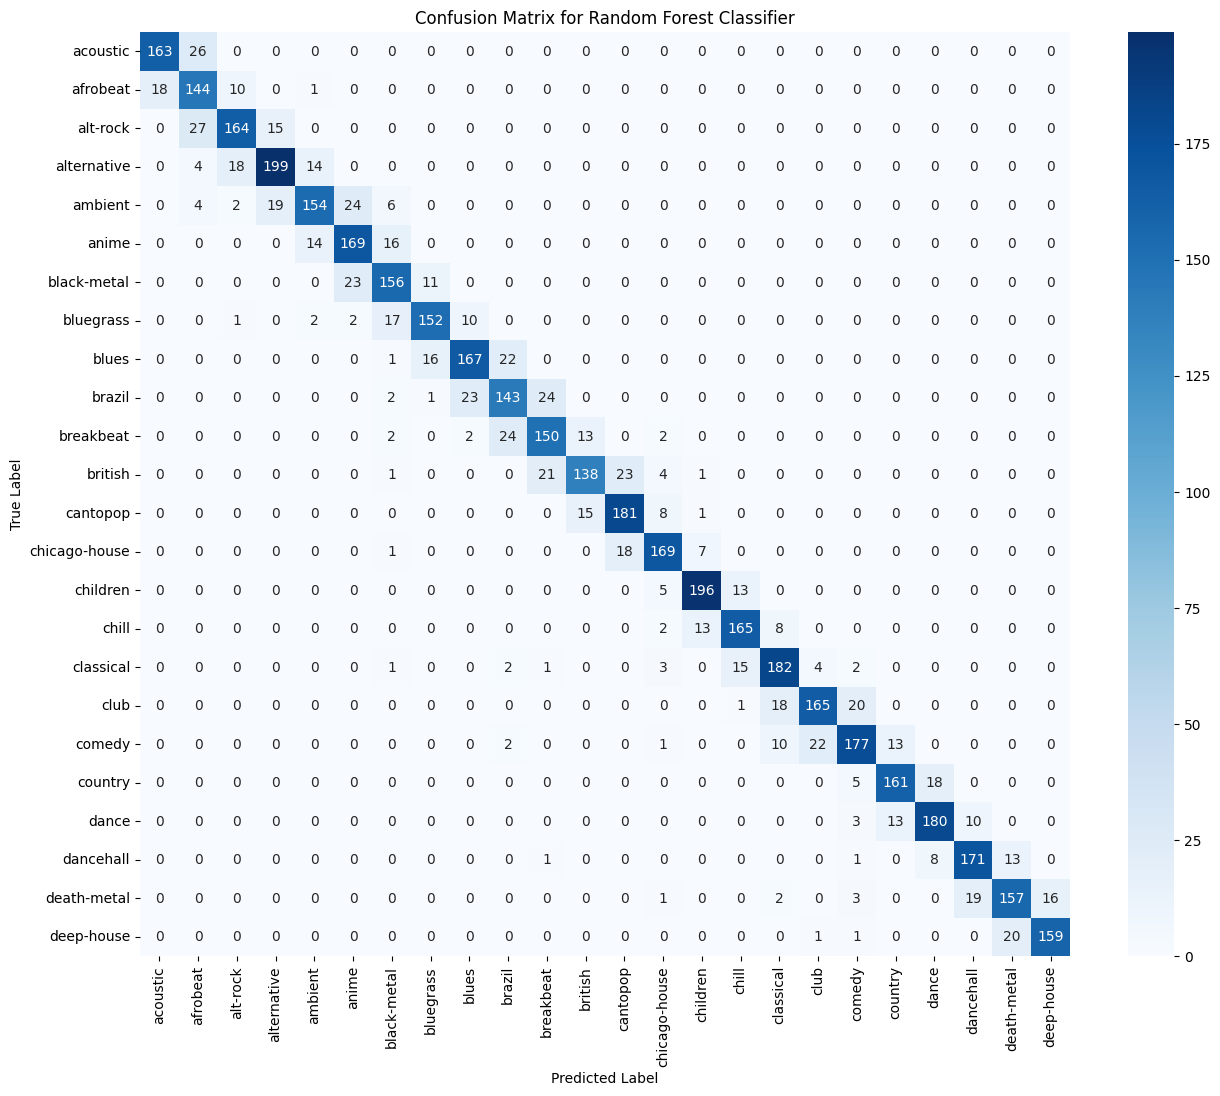

In [113]:
plt.figure(figsize=(15, 12))
sns.heatmap(confusion_matrix(knnYtest, y_pred_knn), annot=True, fmt='d', cmap='Blues',
            xticklabels=knn.classes_, yticklabels=knn.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

como podemos ver, la exactitud de nuestro modelo knn es de 83% a comparación de las prueba de modelos anteriores, el primero con menos caracteristicas  (este nos daba 49.3%, lo cual no es muy alentador) ya vemos una mejoria en el modelo aun que sigue confundiendo alt-rock con alternative cuando escalamos los datos con StandardScaler dandonos una exactitud de 71.35%,  pero ahora voy a usar un modelo que predice mejor variables objetivo multiclase como randomforest para observar el diferente resultado usando StandardScaler en dicho modelo

In [119]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(knnXtrain_scaled, knnYtrain)

RandomForestClassifier(random_state=42)

Accuracy of Random Forest model: 0.9834346823233382

Classification Report for Random Forest:
                precision    recall  f1-score   support

     acoustic       1.00      1.00      1.00       189
     afrobeat       1.00      1.00      1.00       173
     alt-rock       0.94      0.99      0.96       206
  alternative       0.97      0.94      0.95       235
      ambient       0.99      0.98      0.98       209
        anime       0.97      0.96      0.97       199
  black-metal       0.99      0.97      0.98       190
    bluegrass       0.98      0.99      0.99       184
        blues       0.97      0.99      0.98       206
       brazil       0.98      0.97      0.98       193
    breakbeat       0.96      0.99      0.98       193
      british       0.99      0.97      0.98       188
     cantopop       1.00      1.00      1.00       205
chicago-house       0.99      1.00      1.00       195
     children       0.99      0.98      0.98       214
        chill       0.97

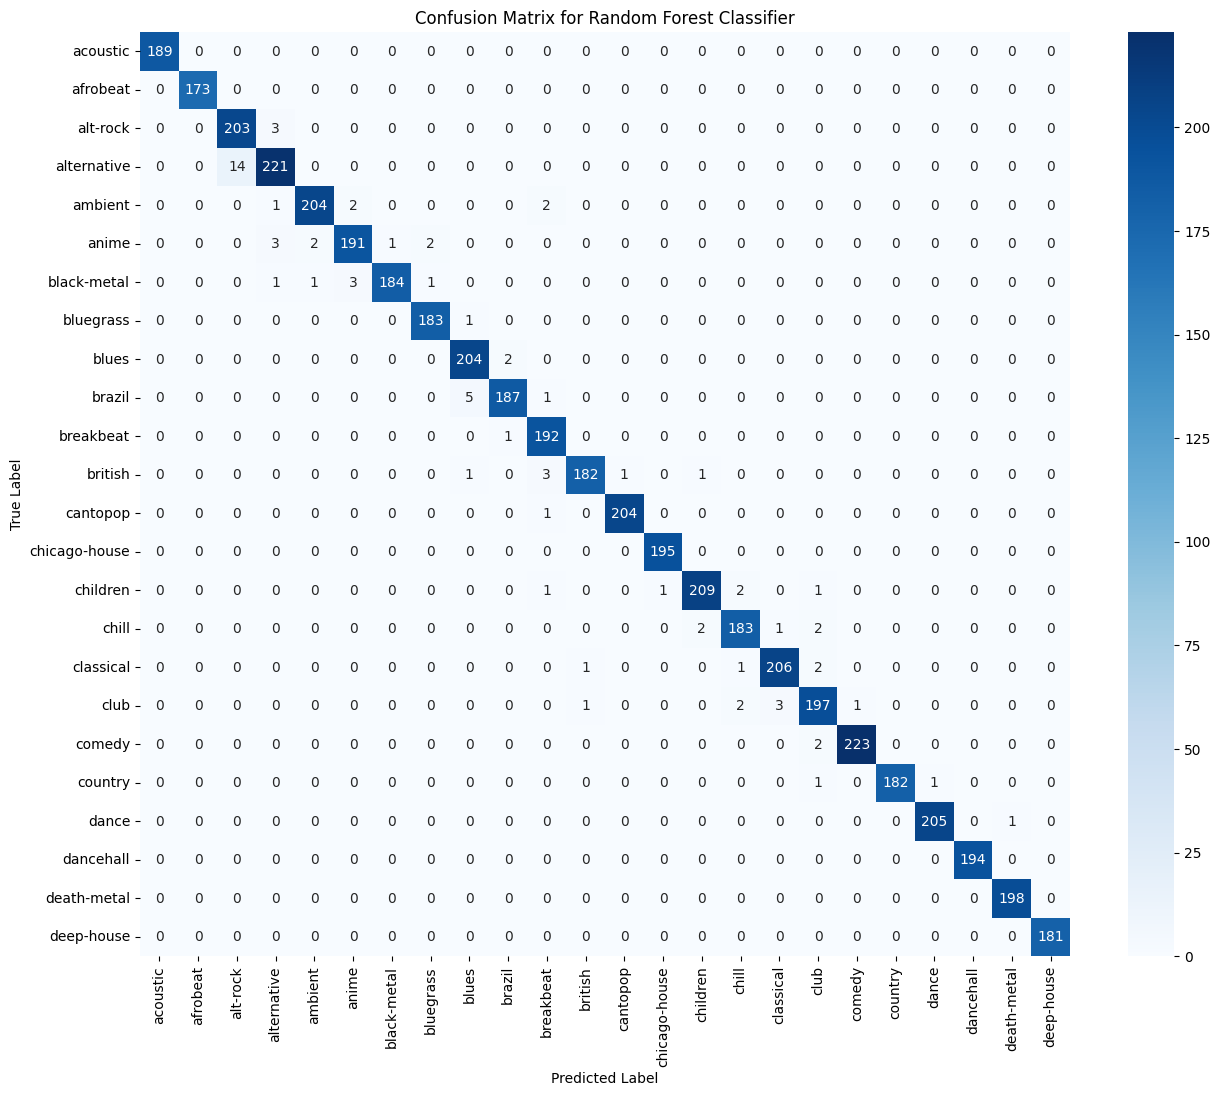

In [120]:
y_pred_rf = rf_model.predict(knnXtest_scaled)

print("Accuracy of Random Forest model:", accuracy_score(knnYtest, y_pred_rf))
print("\nClassification Report for Random Forest:\n", classification_report(knnYtest, y_pred_rf))


plt.figure(figsize=(15, 12))
sns.heatmap(confusion_matrix(knnYtest, y_pred_rf), annot=True, fmt='d', cmap='Blues',
            xticklabels=rf_model.classes_, yticklabels=rf_model.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

ya vemos que la exactitud de nuestro modelo aumento aun muy buen porcentaje de exactitud (98.34%) pero si observamos la matriz de confusión, especificamente la diagonal principal y la comparamos con la de nuestro modelo de KNN vemos que ya distingue casi sin error cada genero, pero con randomforest usamos StandardScaler y obtuvimos un mejor resultado, (pero por que random forest es mejor para clasificación multiclase y si usamos nuestros datos de entrenamiento sin StandarScaler conseguiremos una exactitud de 98.32%)